# EEG Config Sweep Notebook
Define your configs in **Cell 2**, run all cells, compare results at the bottom.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from IPython.display import display

# Import everything from your refactored pipeline
from eeg_experiment_loso import (
    ExperimentConfig,
    load_all_subjects,
    evaluate_all,
)

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print(' Imported ')

 Imported 


## 🔧 Define Your Configs Here
Add as many `ExperimentConfig(...)` entries as you like. Give each a short `name`.

In [10]:
name = 'ICA_norm_1.0w_0.8ov'
type = 'LOSO'

In [3]:
SWEEP = [
    # {
    #     'name': 'ICA_norm',
    #     'config': ExperimentConfig(
    #         time_window=1.5,
    #         overlap_factor=0.8,
    #         l_freq=2.0,
    #         h_freq=80.0,
    #         apply_ica=True,
    #         cov_estimator='oas',
    #         ts_metric='riemann',
    #         classifiers=['logreg', 'svm'],
    #     )
    # },
    {
        'name': 'ICA_norm_1.0w_0.5ov',
        'config': ExperimentConfig(
            time_window=1.0,
            overlap_factor=0.8,
            l_freq=2.0,
            h_freq=80.0,
            apply_ica=True,
            cov_estimator='oas',
            ts_metric='riemann',
            classifiers=['svm'],
        
        )
    },
    {
        'name': 'ICA_0.5w_0.50v',
        'config': ExperimentConfig(
            time_window=0.5,
            overlap_factor=0.8,
            l_freq=2.0,
            h_freq=100.0,
            apply_ica=True,
            cov_estimator='oas',
            ts_metric='riemann',
            classifiers=[ 'svm'],
        )
    },
]

print(f'Sweep defined: {len(SWEEP)} configs')
for entry in SWEEP:
    c = entry['config']
    print(f"  [{entry['name']}]  tw={c.time_window}s  overlap={c.overlap_factor}  "
          f"ica={c.apply_ica}  band={c.l_freq}-{c.h_freq}Hz  "
          f"cov={c.cov_estimator}  ts={c.ts_metric}  clfs={c.classifiers}")

Sweep defined: 2 configs
  [ICA_norm_1.0w_0.5ov]  tw=1.0s  overlap=0.8  ica=True  band=2.0-80.0Hz  cov=oas  ts=riemann  clfs=['svm']
  [ICA_0.5w_0.50v]  tw=0.5s  overlap=0.8  ica=True  band=2.0-100.0Hz  cov=oas  ts=riemann  clfs=['svm']


## ▶️ Run the Sweep
Loads data once per config (ICA is the slow part). Results stored in `RESULTS`.

In [4]:
RESULTS = []   # list of dicts: {name, config, acc_dict}

for entry in SWEEP:
    name   = entry['name']
    config = entry['config']
    print(f'\n{"="*55}\n🚀  Running config: {name}\n{"="*55}')

    # suppress per-config confusion matrix plots — we'll make our own below
    config.show_plots = False
    config.save_confusion_matrices = False

    total_data  = load_all_subjects(config)
    acc_dict = evaluate_all(total_data, config)

    # # Also keep raw predictions for confusion matrices
    # pred_store = {}
    # from eeg_experiment import riemannian_predict
    # for clf_type in config.classifiers:
    #     pred_store[clf_type] = {}
    #     for test_subject in total_data:
    #         test_dict = {test_subject: total_data[test_subject]}

  
    #         y_pred = riemannian_predict(
    #             total_data[subject]['data'], total_data[subject]['labels'],
    #               clf_type, config
    #         )
    #         pred_store[clf_type][subject] = {
    #             'y_true': test_data[subject]['labels'],
    #             'y_pred': y_pred,
    #         }

    RESULTS.append({
        'name':       name,
        'config':     config,
        'acc_dict':   acc_dict
        #'pred_store': pred_store,
    })
    print(f'✅  Done: {name}')

print('\n🏁 All configs finished.')


🚀  Running config: ICA_norm_1.0w_0.5ov
Found 15 subjects: ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114']

Processing S116
  [1] VI_S6_S1_B3__20251116_110436.mff
🔧 ICA: 25 components on 100 channels …
  EOG_vertical: [0, 1]
  EOG_horizontal: [0]
  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Channels: 100
✅ Baseline: BLCS/BLCE
  [2] VI_SX_S2_B1_1__20260315_022327.mff
🔧 ICA: 25 components on 100 channels …
  EOG_vertical: [0, 1]
  EOG_horizontal: [0]
  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Channels: 100
✅ Baseline: BLCS/BLCE
  [3] VI_S6_S1_B1__20251116_104819.mff
🔧 ICA: 25 components on 100 channels …
  EOG_vertical: [0, 1]
  EOG_horizontal: []
  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Channels: 100
✅ Baseline: BLCS/BLCE
  [4] VI_SX_S2_B2_2__20260315_023302.mff
🔧 ICA: 25 components on 100 channels …
  EOG_vertical: [0]
  EOG_horizontal: [0]
  Excluding 1/25 components: [0]
  ✅ ICA done. Channels: 100
✅ Base

KeyboardInterrupt: 

In [5]:
RESULTS

[{'name': 'ICA_norm_1.0w_0.5ov',
  'config': ExperimentConfig(base_dir='/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data', time_window=1.0, overlap_factor=0.8, start_offset=0.5, end_offset=0.5, fs=500.0, l_freq=2.0, h_freq=80.0, notch_freq=50.0, apply_ica=True, remove_muscle=False, ica_n_components=25, ica_eog_threshold=3.5, ica_max_iter=500, eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32'), active_channels=['E24', 'E124', 'E36', 'E104', 'E47', 'E52', 'E60', 'E67', 'E72', 'E77', 'E85', 'E92', 'E98', 'E62', 'E70', 'E75', 'E83', 'E58', 'E96', 'E90', 'E65', 'E69', 'E74', 'E82', 'E89', 'E1', 'E32', 'E14', 'E21'], bad_channels=['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114', 'E127', 'E126', 'E68', 'E23', 'E3', 'E49', 'E48', 'E8', 'E25', 'E56', 'E63', 'E99', 'E107'], classes=['BA', 'BY', 'SI'], label_dict={'IMBA': 0, 'IMBY': 1, 'IMSI': 2}, normalize=True, classifiers=['svm'], logreg_C=1.0, logreg_max_i

## 📊 Summary Table

In [6]:
# Build a flat DataFrame: rows = (config, classifier, subject), col = accuracy
rows = []
for res in RESULTS:
    for clf_type, subj_acc in res['acc_dict'].items():
        for subject, acc in subj_acc.items():
            rows.append({
                'config':     res['name'],
                'classifier': clf_type,
                'subject':    subject,
                'accuracy':   acc,
            })

df = pd.DataFrame(rows)

# Pivot: configs × classifiers as columns, subjects as rows
df['run'] = df['config'] + ' / ' + df['classifier']
pivot = df.pivot_table(index='subject', columns='run', values='accuracy')

# Append a mean row
pivot.loc['MEAN'] = pivot.mean()

# Style: highlight best in each row
styled = (
    pivot.style
    .format('{:.3f}')
    .highlight_max(axis=1, color='#c6efce')   # green = best per row
    .highlight_min(axis=1, color='#ffc7ce')   # red   = worst per row
    .set_caption('Accuracy by Subject × Config/Classifier  |  green=best  red=worst')
)
display(styled)

# Also save as CSV
csv_path = f'{type}_{name}sweep_results.csv'
pivot.to_csv(csv_path)
print(f'\n📁 Saved to {csv_path}')

run,ICA_norm_1.0w_0.5ov / svm
subject,
S1,0.345
S113,0.326
S114,0.317
S115,0.396
S116,0.411
S117,0.336
S118,0.319
S119,0.384
S1_,0.294



📁 Saved to LOSO_ICA_0.5w_0.50vsweep_results.csv


## 📈 Accuracy Bar Charts — Per Subject

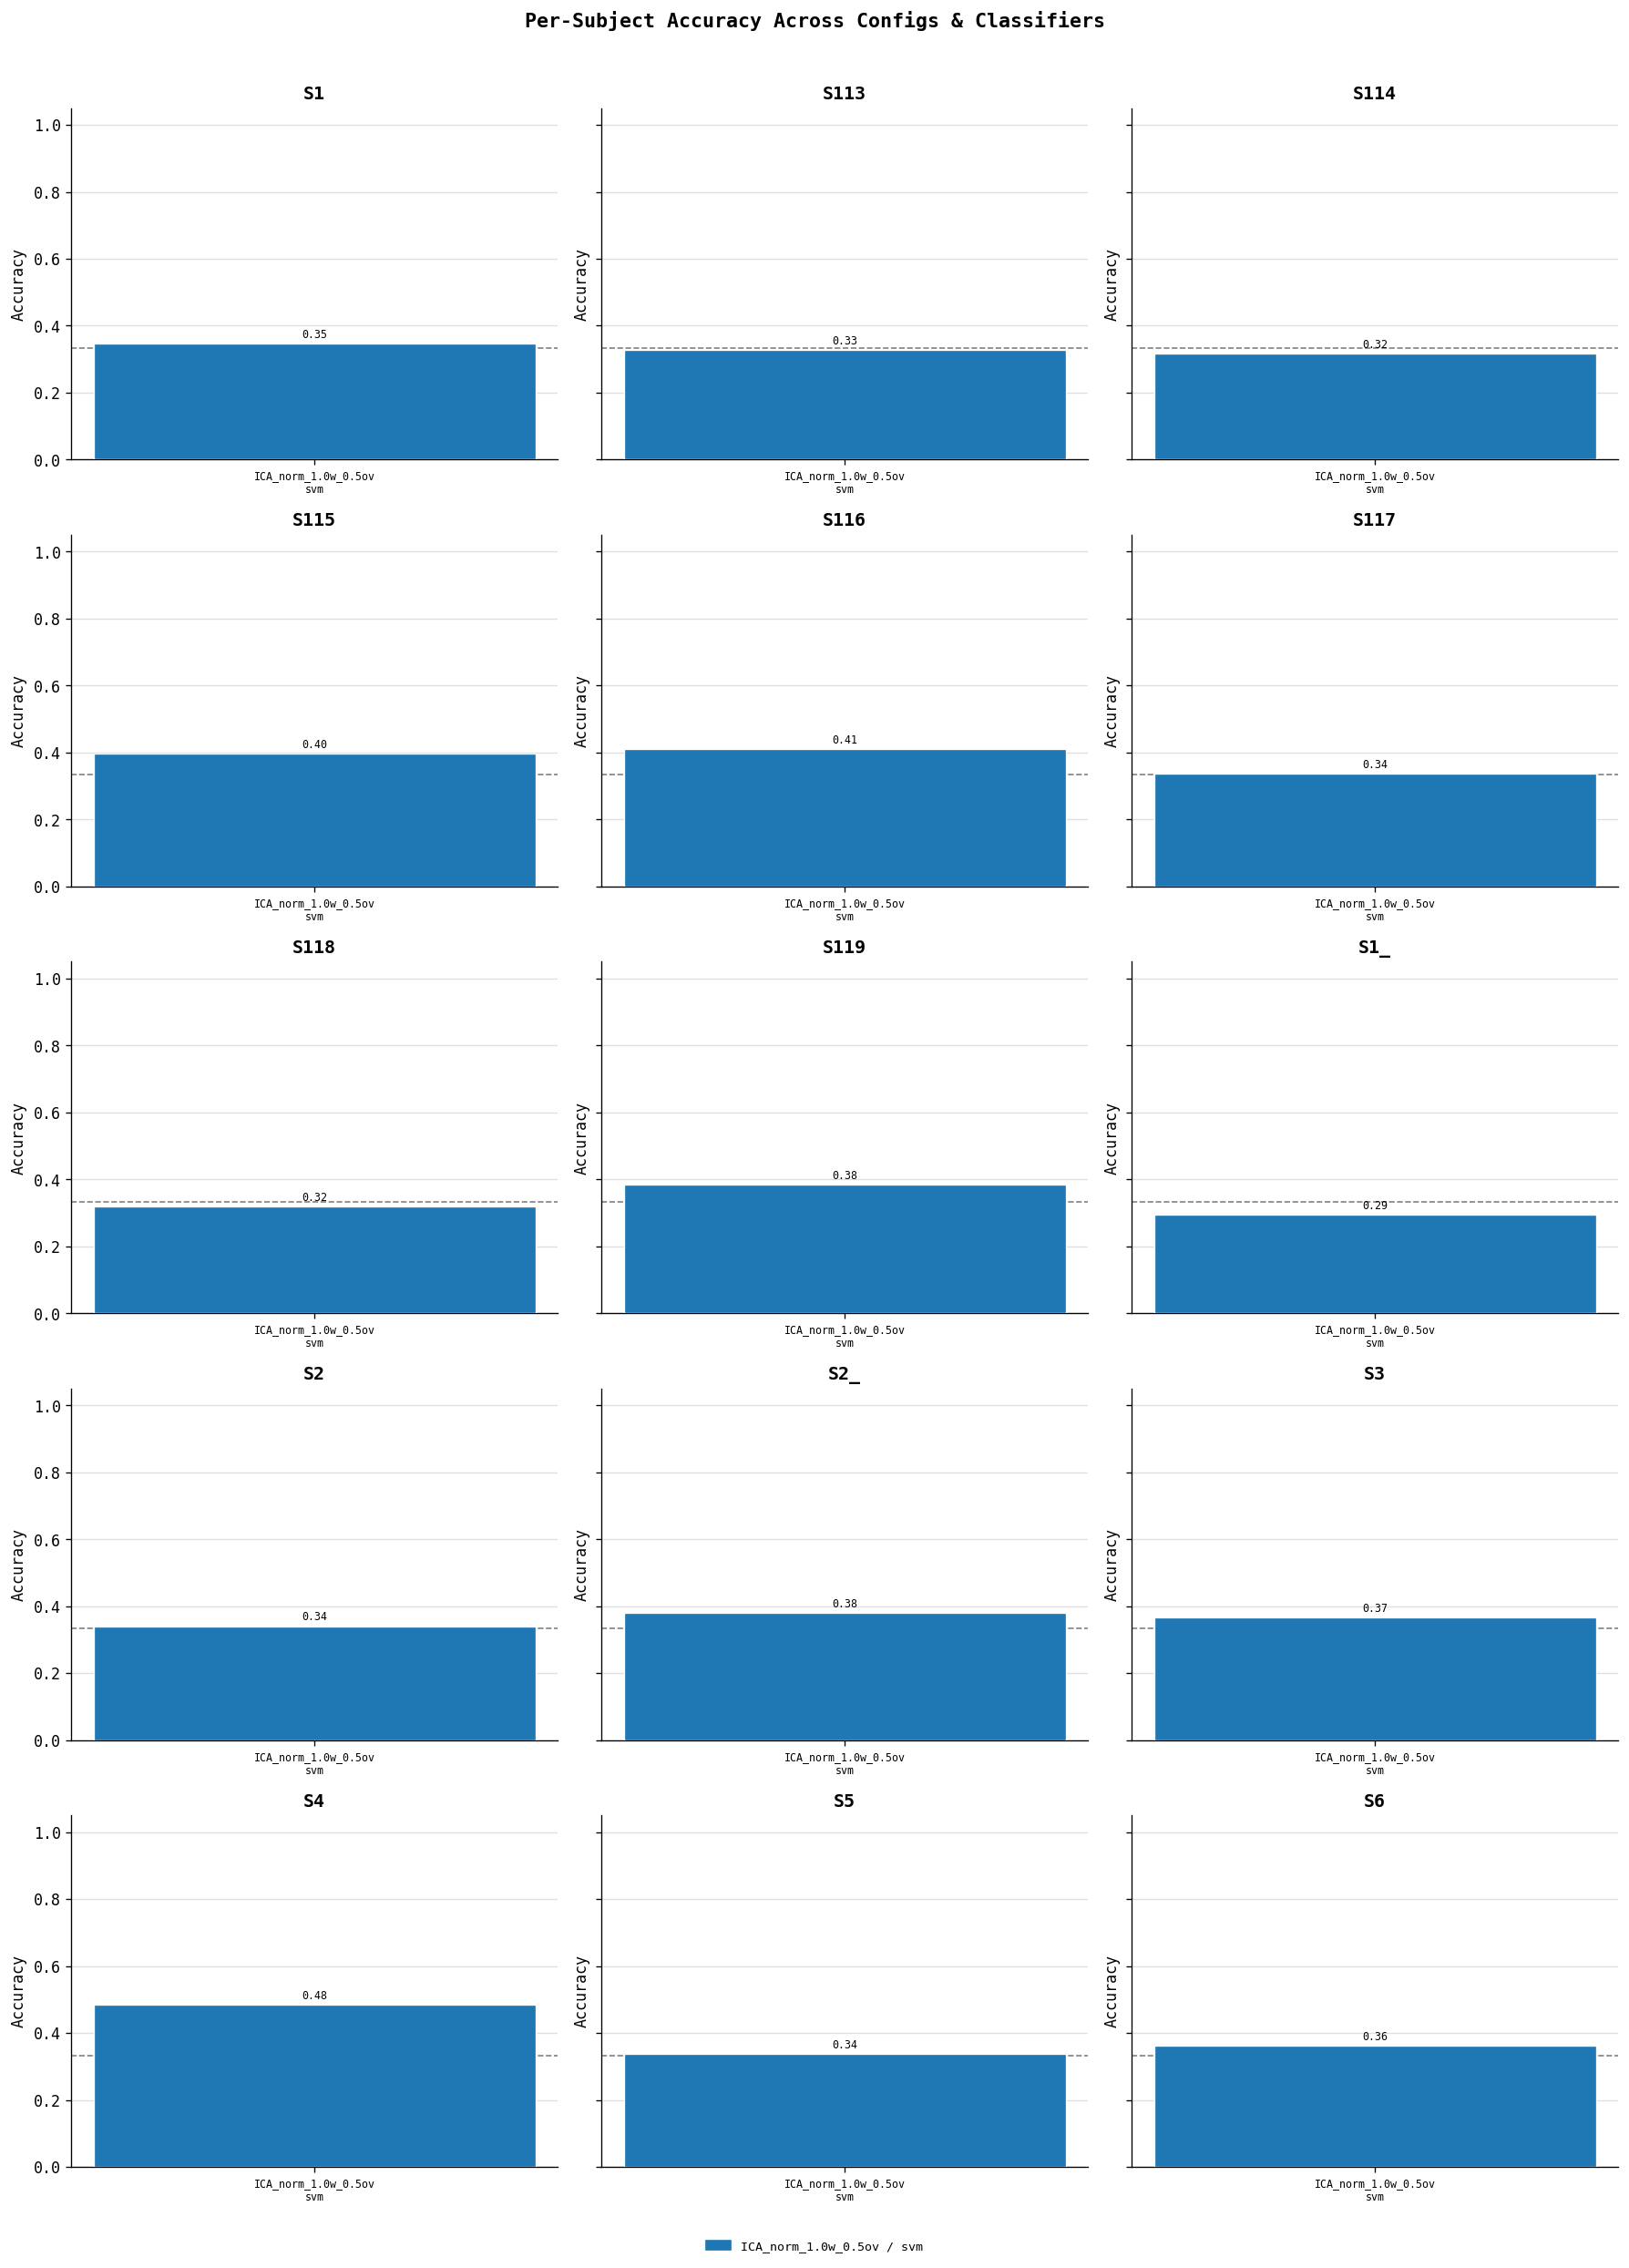

📁 Saved accuracy_by_subject.png


In [11]:
subjects  = sorted(df['subject'].unique())
runs      = sorted(df['run'].unique())
palette   = sns.color_palette('tab10', n_colors=len(runs))
color_map = dict(zip(runs, palette))

n_subj = len(subjects)
ncols  = min(3, n_subj)
nrows  = (n_subj + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(5 * ncols, 4 * nrows),
                          sharey=True)
axes_flat = np.array(axes).flatten()

chance = 1 / len(RESULTS[0]['config'].classes)

for i, subj in enumerate(subjects):
    ax   = axes_flat[i]
    sdf  = df[df['subject'] == subj].set_index('run')['accuracy'].reindex(runs)
    bars = ax.bar(range(len(runs)), sdf.values,
                  color=[color_map[r] for r in runs],
                  edgecolor='white', linewidth=0.8, zorder=3)

    # Chance line
    ax.axhline(chance, color='grey', linestyle='--', linewidth=1,
               label=f'chance ({chance:.2f})', zorder=2)

    # Value labels
    for bar, val in zip(bars, sdf.values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(subj, fontweight='bold')
    ax.set_xticks(range(len(runs)))
    ax.set_xticklabels([r.replace(' / ', '\n') for r in runs],
                        fontsize=7, rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Accuracy')
    ax.yaxis.grid(True, alpha=0.4, zorder=0)

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Legend (one per run/colour)
handles = [plt.Rectangle((0,0),1,1, color=color_map[r]) for r in runs]
fig.legend(handles, runs, loc='lower center', ncol=len(runs),
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Per-Subject Accuracy Across Configs & Classifiers',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{type}_{name}accuracy_by_subject.png', bbox_inches='tight', dpi=150)
plt.show()
print('📁 Saved accuracy_by_subject.png')

## 🔲 Confusion Matrices — Side by Side
One row per subject, one column per (config × classifier) run.

KeyError: 'pred_store'

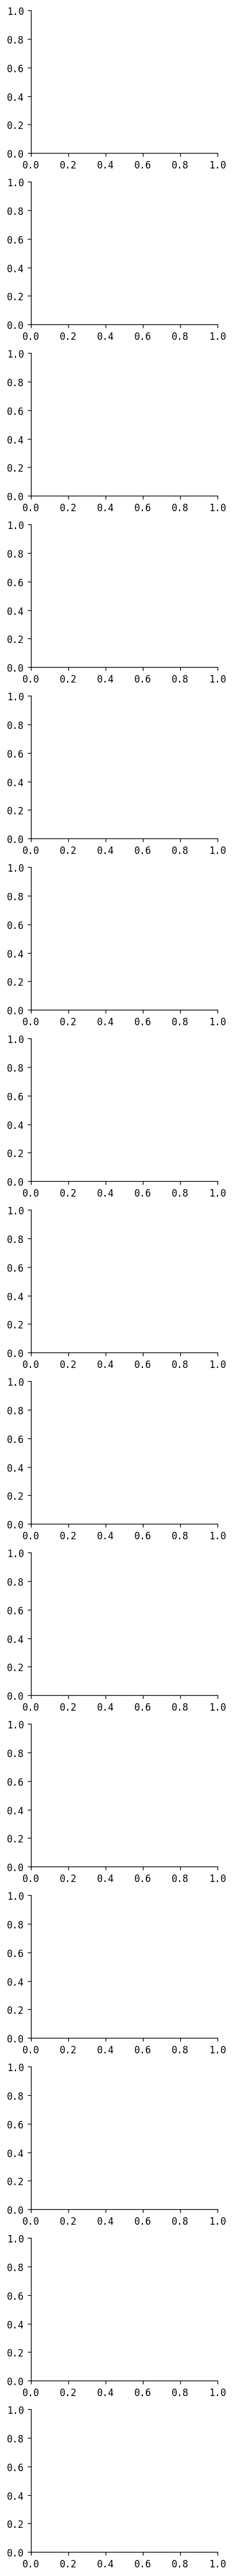

In [12]:
from sklearn.metrics import confusion_matrix

# Build list of all (config_name, clf_type) combos in order
runs_list = [
    (res['name'], clf_type)
    for res in RESULTS
    for clf_type in res['config'].classifiers
]

class_names = RESULTS[0]['config'].classes
n_cols = len(runs_list)
n_rows = len(subjects)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(3.5 * n_cols, 3.2 * n_rows))

# Ensure 2D even with 1 row or 1 col
if n_rows == 1: axes = axes[np.newaxis, :]
if n_cols == 1: axes = axes[:, np.newaxis]

cmap = LinearSegmentedColormap.from_list('eeg_blues', ['#f7fbff', '#08519c'])

for row_i, subj in enumerate(subjects):
    for col_j, (cfg_name, clf_type) in enumerate(runs_list):
        ax = axes[row_i, col_j]

        # Find matching result
        res  = next(r for r in RESULTS if r['name'] == cfg_name)
        preds = res['pred_store'].get(clf_type, {}).get(subj)

        if preds is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes)
            ax.axis('off')
            continue

        cm  = confusion_matrix(preds['y_true'], preds['y_pred'], normalize='true')
        acc = np.diag(cm).mean()

        im = ax.imshow(cm, vmin=0, vmax=1, cmap=cmap, aspect='auto')

        # Cell text
        for r in range(len(class_names)):
            for c in range(len(class_names)):
                ax.text(c, r, f'{cm[r, c]:.2f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if cm[r, c] > 0.6 else 'black')

        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, fontsize=7)
        ax.set_yticklabels(class_names if col_j == 0 else [], fontsize=7)

        if row_i == 0:
            ax.set_title(f'{cfg_name}\n{clf_type}', fontsize=8, fontweight='bold')
        if col_j == 0:
            ax.set_ylabel(subj, fontsize=9, fontweight='bold')

        ax.set_xlabel(f'acc={acc:.2f}', fontsize=7)

fig.suptitle('Confusion Matrices  |  rows=subjects  cols=config/classifier',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{type}_{name}_confusion_matrices_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print('📁 Saved confusion_matrices_grid.png')

## 🏆 Overall Mean Accuracy — Quick Comparison

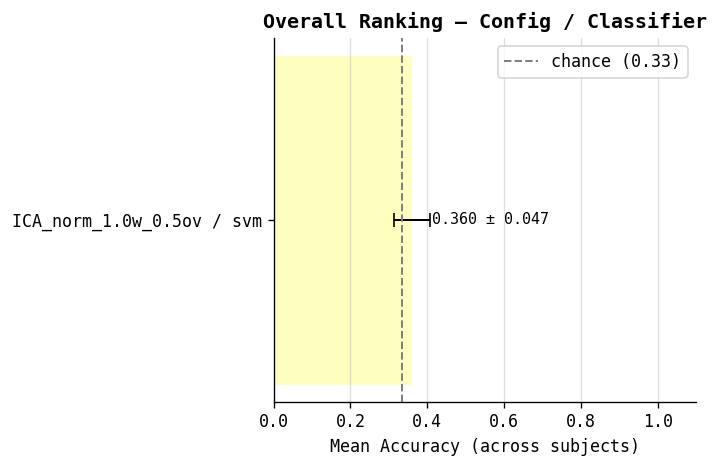

📁 Saved overall_ranking.png


In [14]:
mean_acc = df.groupby('run')['accuracy'].agg(['mean', 'std']).sort_values('mean', ascending=False)
mean_acc.columns = ['mean_acc', 'std_acc']

fig, ax = plt.subplots(figsize=(max(6, len(mean_acc) * 1.4), 4))
colors = sns.color_palette('RdYlGn', n_colors=len(mean_acc))

bars = ax.barh(mean_acc.index, mean_acc['mean_acc'],
               xerr=mean_acc['std_acc'], color=colors,
               edgecolor='white', linewidth=0.8,
               error_kw=dict(elinewidth=1.2, capsize=4))

ax.axvline(chance, color='grey', linestyle='--', linewidth=1.2,
           label=f'chance ({chance:.2f})')

for bar, (_, row) in zip(bars, mean_acc.iterrows()):
    ax.text(row['mean_acc'] + row['std_acc'] + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{row['mean_acc']:.3f} ± {row['std_acc']:.3f}",
            va='center', fontsize=9)

ax.set_xlabel('Mean Accuracy (across subjects)')
ax.set_title('Overall Ranking — Config / Classifier', fontweight='bold')
ax.set_xlim(0, 1.1)
ax.legend()
ax.xaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{type}_{name}overall_ranking.png', bbox_inches='tight', dpi=150)
plt.show()
print('📁 Saved overall_ranking.png')

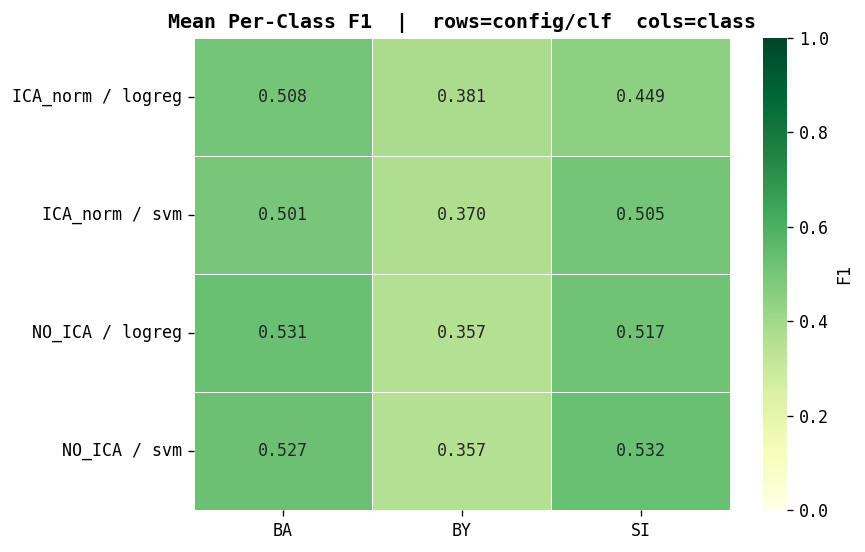

📁 Saved f1_per_class.png


In [ ]:
from sklearn.metrics import f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Build per-class F1 for every (config, clf, subject) ──────────────────────
f1_rows = []
class_names = RESULTS[0]['config'].classes

for res in RESULTS:
    for clf_type, subj_preds in res['pred_store'].items():
        for subject, preds in subj_preds.items():
            f1s = f1_score(preds['y_true'], preds['y_pred'],
                           average=None, labels=list(range(len(class_names))))
            for cls_i, cls_name in enumerate(class_names):
                f1_rows.append({
                    'run':     f"{res['name']} / {clf_type}",
                    'subject': subject,
                    'class':   cls_name,
                    'f1':      f1s[cls_i],
                })

df_f1 = pd.DataFrame(f1_rows)

# ── Heatmap: mean F1 per class across subjects, for each run ─────────────────
pivot_f1 = df_f1.groupby(['run', 'class'])['f1'].mean().unstack()   # rows=run, cols=class

fig, ax = plt.subplots(figsize=(len(class_names) * 1.8 + 2, len(pivot_f1) * 0.8 + 1.5))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', vmin=0, vmax=1,
            cmap='YlGn', linewidths=0.5, ax=ax, cbar_kws={'label': 'F1'})
ax.set_title('Mean Per-Class F1  |  rows=config/clf  cols=class', fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{type}_{SWEEP['name']}f1_per_class.png', bbox_inches='tight', dpi=150)
plt.show()
print('📁 Saved f1_per_class.png')

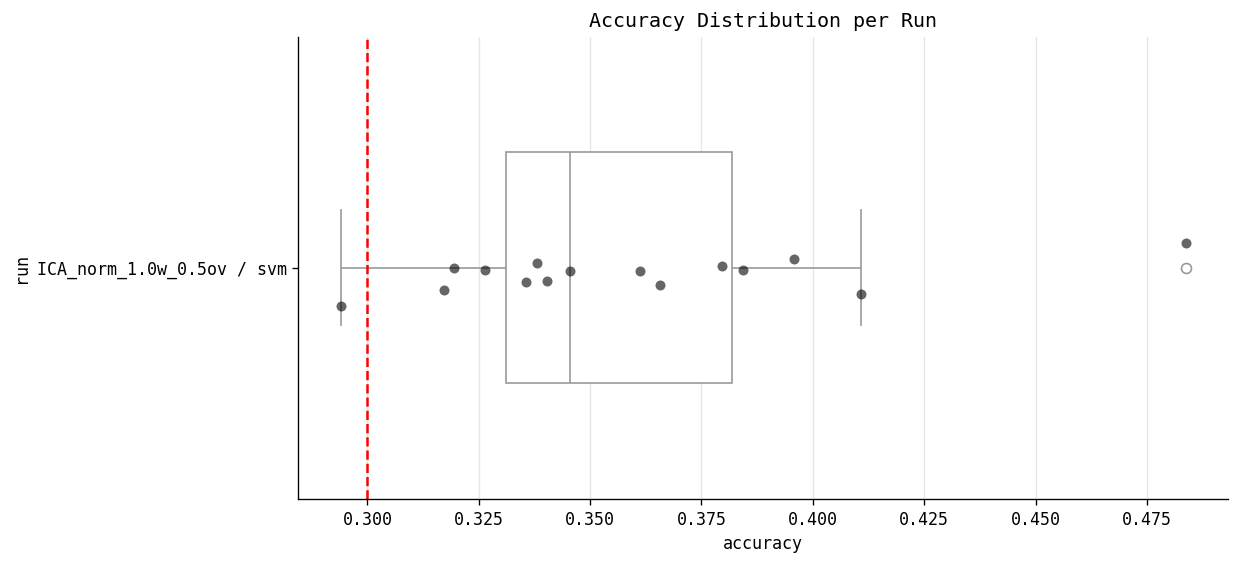

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# 1. Draw the boxplot to show quartiles
sns.boxplot(data=df, x='accuracy', y='run', color='white', width=0.5)

# 2. Overlay the actual data points so you can see the 0.145 value
sns.stripplot(data=df, x='accuracy', y='run', color='black', alpha=0.6, size=6)

plt.axvline(0.3, color='red', linestyle='--', label='Chance (0.3)')
plt.title('Accuracy Distribution per Run')
plt.grid(axis='x', alpha=0.3)
plt.savefig(f"{name}_{type}_accuracy_dist.png")
plt.show()